# WP4 period prior: analysis of the 10,000-member ensemble

The sediment-hosted prior (WP4-A-SH v0.7) was run on Sherlock for seeds 3000 to 12999. Each member was forward-modelled and sampled at the 342 BMR gravity stations (1969) and 24,980 P234 magnetic readings (1962), with survey noise. This notebook asks what the t0 surveys already say about the prior, before any class comparison.

1. What the 10,000 realizations contain
2. The Section 4 gate on 10,000 members
3. The falsification screen, member by member
4. Prior falsification by robust Mahalanobis distance
5. Observed and simulated profiles
6. Which prior draws the surveys constrain
7. What the screen does to the ore question
8. Point-wise misfit and why weighting collapses
9. Next steps

Run from the `SVOI_OD` folder. Inputs: `08_prior_models/gen_n10000/` (`pred_all.npz`, `draws_all.csv`, `observed.npz`) and `09_sherlock/svoi_core.py` (grid, anomaly rule, observed surveys, sampler). Figures go to `08_prior_models/figures/wp4_ENS_*.png`.

In [1]:
# --- journal figure style ---------------------------------------------------
# Every text element has an explicit size; figures are drawn at final printed
# width so the point sizes below are the sizes that reach the page.
import matplotlib.pyplot as plt

FS_TICK, FS_LABEL, FS_LEGEND, FS_ANNOT, FS_PANEL = 8, 9, 8, 7, 9
COL1, COL15, COL2 = 3.5, 5.5, 7.2      # single / 1.5 / double column width (in)

plt.rcParams.update({
    # typeface
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "mathtext.fontset": "dejavusans",
    "font.size": FS_TICK,
    # text elements
    "axes.labelsize": FS_LABEL,
    "axes.titlesize": FS_PANEL,
    "xtick.labelsize": FS_TICK,
    "ytick.labelsize": FS_TICK,
    "legend.fontsize": FS_LEGEND,
    "legend.title_fontsize": FS_LEGEND,
    "figure.titlesize": FS_LABEL,
    # axes furniture: thin frame, ticks inward on all four sides, minor ticks
    "axes.linewidth": 0.6,
    "axes.grid": False,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
    "xtick.minor.visible": True, "ytick.minor.visible": True,
    "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "xtick.minor.width": 0.4, "ytick.minor.width": 0.4,
    "xtick.major.size": 3.0, "ytick.major.size": 3.0,
    "xtick.minor.size": 1.8, "ytick.minor.size": 1.8,
    # marks
    "lines.linewidth": 1.0,
    "lines.markersize": 3.0,
    "legend.frameon": False,
    "legend.handlelength": 1.6,
    "legend.borderaxespad": 0.4,
    # output
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
})

def panel_labels(axes, labels=("(a)", "(b)")):
    """Bold (a)/(b) above the top-left corner of each axes."""
    for ax, lab in zip(axes, labels):
        ax.set_title(lab, loc="left", fontsize=FS_PANEL, fontweight="bold")

# --- batlow: Crameri's scientific colour map (Crameri et al. 2020, Nat. Commun.)
# 32 anchor points interpolated to 256 steps; reproduces the published map to
# within 1.4/255 per channel. Embedded so the notebook needs no extra package.
from matplotlib.colors import LinearSegmentedColormap
_BATLOW = [
    (0.0052, 0.0982, 0.3498), (0.0321, 0.1468, 0.3582), (0.0494, 0.1911, 0.3658), (0.0592, 0.2298, 0.3723),
    (0.0679, 0.2671, 0.3782), (0.0771, 0.2970, 0.3824), (0.0903, 0.3257, 0.3849), (0.1097, 0.3531, 0.3842),
    (0.1413, 0.3812, 0.3771), (0.1778, 0.4030, 0.3638), (0.2201, 0.4219, 0.3443), (0.2662, 0.4386, 0.3201),
    (0.3208, 0.4560, 0.2898), (0.3709, 0.4711, 0.2621), (0.4225, 0.4861, 0.2345), (0.4762, 0.5013, 0.2081),
    (0.5402, 0.5186, 0.1831), (0.6005, 0.5336, 0.1706), (0.6627, 0.5475, 0.1740), (0.7243, 0.5596, 0.1954),
    (0.7906, 0.5714, 0.2362), (0.8457, 0.5817, 0.2826), (0.8958, 0.5938, 0.3379), (0.9378, 0.6096, 0.4023),
    (0.9708, 0.6324, 0.4833), (0.9864, 0.6555, 0.5571), (0.9923, 0.6790, 0.6283), (0.9930, 0.7020, 0.6958),
    (0.9914, 0.7276, 0.7703), (0.9891, 0.7510, 0.8380), (0.9860, 0.7753, 0.9084), (0.9814, 0.8004, 0.9813),
]
BATLOW = LinearSegmentedColormap.from_list("batlow", _BATLOW, N=256)

import matplotlib.patheffects as _pe
HALO = [_pe.withStroke(linewidth=1.6, foreground="white")]   # keeps markers and
# labels legible where they sit on a filled colour field

## Data

Loads the ensemble and the same grid, anomaly rule and observed surveys the prior notebook uses (through `svoi_core`, so the rule cannot drift). The check confirms the seeds are complete and the observed data in the ensemble folder are the ones the rule was fixed on.

In [2]:
import sys, io, contextlib, time
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import sparse, ndimage, stats

sys.path.insert(0, "09_sherlock")
with contextlib.redirect_stdout(io.StringIO()):          # svoi_core prints its setup; keep the notebook quiet
    import svoi_core as C

GEN = Path("08_prior_models/gen_n10000")
FIG = Path("08_prior_models/figures"); FIG.mkdir(parents=True, exist_ok=True)
DR = pd.read_csv(GEN / "draws_all.csv")
z = np.load(GEN / "pred_all.npz"); SEEDS, PRED_G = z["seeds"], z["grav"]     # magnetics (1 GB) is read in Step 2
ob = np.load(GEN / "observed.npz")

assert (DR.seed.values == SEEDS).all() and np.array_equal(SEEDS, np.arange(SEEDS.min(), SEEDS.max() + 1))
assert np.allclose(ob["grav"], C.G_OBS) and np.allclose(ob["mag"], C.M_OBS) and np.allclose(ob["grav_x"], C.GXo)
N = len(SEEDS)
DRAW_COLS = [c for c in DR.columns if c[:2] in ("L1", "L2", "L3", "L4", "L5")]
print(f"{N:,} realizations, seeds {SEEDS.min()}-{SEEDS.max()}, none missing")
print(f"gravity {PRED_G.shape}, magnetics ({N}, {len(C.M_OBS)}); {len(DRAW_COLS)} draw columns, {DR.shape[1]} columns in total")
print(f"observed surveys identical to the ones the Section 4 rule was fixed on: True")

10,000 realizations, seeds 3000-12999, none missing
gravity (10000, 398), magnetics (10000, 37095); 18 draw columns, 29 columns in total
observed surveys identical to the ones the Section 4 rule was fixed on: True


## Step 1. What the 10,000 realizations contain

Before any data enter: how many basalt piles, iron-oxide bodies and ore patches the prior puts in the 13,560 km$^2$ window, and how much ore.

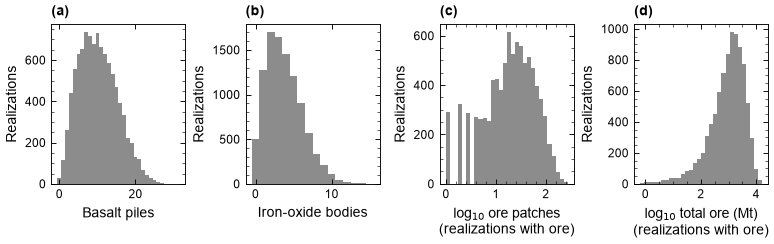

basalt piles per realization: median 10, range 0-31; none in 0.3%
iron-oxide bodies: median 3, range 0-15; none in 5.0%
realizations with no ore anywhere in the window: 12.2%
with ore: patches median 21, total ore median 1,150 Mt, 90th percentile 4,341 Mt


In [3]:
C_PRIOR, C_KEEP, C_OBS = "#8c8c8c", "#2a78d6", "#c0504d"          # prior ensemble, survivors (Step 3), observed survey
fig, axes = plt.subplots(1, 4, figsize=(COL2, 2.3))
fig.subplots_adjust(left=0.07, right=0.975, top=0.88, bottom=0.25, wspace=0.45)
for ax, col, lab in [(axes[0], "n_basalt", "Basalt piles"), (axes[1], "n_iron", "Iron-oxide bodies")]:
    v = DR[col].values; ax.hist(v, bins=np.arange(-0.5, v.max() + 1.5), color=C_PRIOR)
    ax.set_xlabel(lab); ax.set_ylabel("Realizations"); ax.xaxis.set_minor_locator(plt.NullLocator())
ax = axes[2]; v = DR.n_ore.values
ax.hist(np.log10(v[v > 0]), bins=30, color=C_PRIOR); ax.set_xlabel("log$_{10}$ ore patches\n(realizations with ore)"); ax.set_ylabel("Realizations")
ax = axes[3]; m = DR.Mt_total.values
ax.hist(np.log10(m[m > 0]), bins=30, color=C_PRIOR); ax.set_xlabel("log$_{10}$ total ore (Mt)\n(realizations with ore)"); ax.set_ylabel("Realizations")
panel_labels(axes, ("(a)", "(b)", "(c)", "(d)"))
fig.savefig(FIG / "wp4_ENS_01_ensemble_contents.png", dpi=300)
plt.show()
P_BARREN = (DR.n_ore == 0).mean()
print(f"basalt piles per realization: median {DR.n_basalt.median():.0f}, range {DR.n_basalt.min()}-{DR.n_basalt.max()}; none in {(DR.n_basalt == 0).mean()*100:.1f}%")
print(f"iron-oxide bodies: median {DR.n_iron.median():.0f}, range {DR.n_iron.min()}-{DR.n_iron.max()}; none in {(DR.n_iron == 0).mean()*100:.1f}%")
print(f"realizations with no ore anywhere in the window: {P_BARREN*100:.1f}%")
print(f"with ore: patches median {DR.n_ore[DR.n_ore > 0].median():.0f}, total ore median {DR.Mt_total[DR.Mt_total > 0].median():,.0f} Mt, 90th percentile {np.percentile(m[m > 0], 90):,.0f} Mt")

### How to read this figure

- (a) Basalt piles per realization: median 8, range 0 to 27; 0.6% have none. (b) Iron-oxide bodies: median 3, range 0 to 15; 8.7% have none.
- (c, d) Only realizations with ore, on log axes: median 17 patches and 922 Mt of total ore, 90th percentile 3,555 Mt.
- 14.9% of realizations have no ore anywhere in the 13,560 km$^2$ window. This is a window-scale frequency set by the sampler, not a class prior; the classes and their priors are set at the target (Next steps).

## Step 2. The Section 4 gate on 10,000 members

The same five statistics per survey as the prior notebook (Steps 8 and 12): remove a plane, grid to 1 km, count connected groups of at least 3 cells above 2 mGal or 20 nT, then the count per 10$^4$ km$^2$, the median and 90th-percentile peak, the median width and the residual standard deviation. The gridding is done as one sparse matrix product per survey, which reproduces `anomaly_stats` exactly (checked on three members below) and takes about a minute for all 10,000. The table is cached in `wp4_ensemble_stats_n10000.csv`.

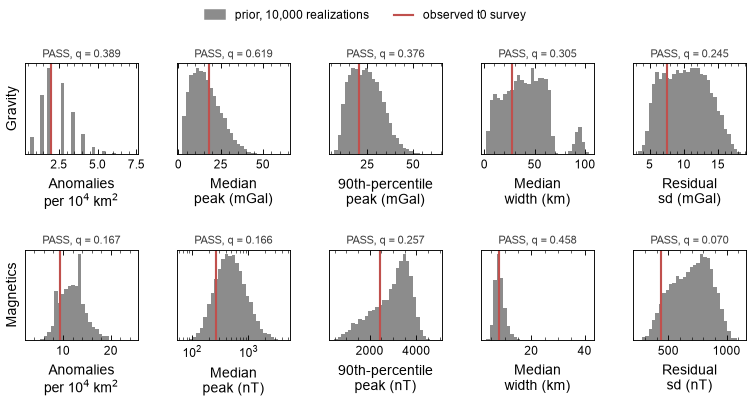

    field       statistic  observed  sim_median  quantile status  n_finite
  gravity    n_per_1e4km2     1.981       1.981     0.389   PASS     10000
  gravity      amp_median    18.059      15.145     0.619   PASS     10000
  gravity         amp_p90    20.613      23.862     0.376   PASS     10000
  gravity width_median_km    27.869      39.961     0.305   PASS     10000
  gravity     residual_sd     7.527      10.245     0.245   PASS     10000
magnetics    n_per_1e4km2     9.452      11.972     0.167   PASS     10000
magnetics      amp_median   263.288     476.795     0.166   PASS     10000
magnetics         amp_p90  2440.613    3138.036     0.257   PASS     10000
magnetics width_median_km     7.818       7.979     0.458   PASS     10000
magnetics     residual_sd   440.406     711.634     0.070   PASS     10000


In [4]:
def grid_weights(tri, GX, GY):
    """linear interpolation from survey points to the 1 km grid as a sparse matrix (same as LinearNDInterpolator)"""
    P = np.c_[GX.ravel(), GY.ravel()]; s = tri.find_simplex(P); ok = s >= 0
    T = tri.transform[s[ok]]; b = np.einsum("nij,nj->ni", T[:, :2], P[ok] - T[:, 2]); bc = np.c_[b, 1 - b.sum(1)]
    W = sparse.csr_matrix((bc.ravel(), (np.repeat(np.flatnonzero(ok), 3), tri.simplices[s[ok]].ravel())), shape=(len(P), tri.npoints))
    return W, ok.reshape(GX.shape)

def plane_projector(x, y):
    A = np.c_[np.ones_like(x), (x - C.X0) / 1e3, (y - C.Y0) / 1e3]
    return A, np.linalg.pinv(A)

def remove_plane(V, P):
    """least-squares plane removed from every row of V (rows are realizations)"""
    A, Ap = P; return V - (V @ Ap.T) @ A.T

def stats_batch(V, W, OK, P, T):
    R = remove_plane(V.astype(np.float64), P)
    G = np.asarray((W @ R.T).T).reshape(len(V), *OK.shape)
    rows = []
    for g, r in zip(G, R):
        lab, n = ndimage.label(OK & (g >= T), structure=np.ones((3, 3)))
        size = ndimage.sum(np.ones_like(g), lab, np.arange(1, n + 1)); keep = size >= C.RULE["min_cells"]
        peak = np.asarray(ndimage.maximum(np.where(OK, g, -np.inf), lab, np.arange(1, n + 1)))[keep]
        width = 2 * np.sqrt(size[keep] / np.pi)
        rows.append(dict(n_per_1e4km2=keep.sum() / OK.sum() * 1e4, amp_median=np.median(peak) if len(peak) else np.nan,
                         amp_p90=np.percentile(peak, 90) if len(peak) else np.nan,
                         width_median_km=np.median(width) if len(width) else np.nan, residual_sd=r.std()))
    return rows

WG, OKG = grid_weights(C.TRI_G, C.GX, C.GY); PG_ = plane_projector(C.GXo, C.GYo)
WM, OKM = grid_weights(C.TRI_M, C.GX, C.GY); PM_ = plane_projector(C.MXo, C.MYo)
for i in range(3):                                                  # exactness check against the prior notebook's rule
    ref = C.anomaly_stats(C.TRI_G, C.GXo, C.GYo, PRED_G[i].astype(float), C.RULE["T_grav_mgal"])[0]
    new = stats_batch(PRED_G[i:i + 1], WG, OKG, PG_, C.RULE["T_grav_mgal"])[0]
    assert all(np.isclose(ref[k], new[k], equal_nan=True) for k in ref)

CACHE = GEN / "wp4_ensemble_stats_n10000.csv"
if CACHE.exists():
    ST = pd.read_csv(CACHE)
else:
    t0 = time.time()
    sg = stats_batch(PRED_G, WG, OKG, PG_, C.RULE["T_grav_mgal"])
    PRED_M = np.load(GEN / "pred_all.npz")["mag"]
    sm, B = [], 500
    for i in range(0, N, B):
        sm += stats_batch(PRED_M[i:i + B], WM, OKM, PM_, C.RULE["T_mag_nt"])
    del PRED_M
    ST = pd.concat([pd.DataFrame({"seed": SEEDS}), pd.DataFrame(sg).add_prefix("g_"), pd.DataFrame(sm).add_prefix("m_")], axis=1)
    ST.to_csv(CACHE, index=False); print(f"statistics computed in {time.time() - t0:.0f} s")
OBS = {"g": C.OBS_G, "m": C.OBS_M}

STATS = [("n_per_1e4km2", "Anomalies\nper 10$^4$ km$^2$", False), ("amp_median", "Median\npeak", True),
         ("amp_p90", "90th-percentile\npeak", True), ("width_median_km", "Median\nwidth (km)", False), ("residual_sd", "Residual\nsd", True)]
UNIT = {"g": "mGal", "m": "nT"}
def gate(sim, obs):
    sim = np.asarray(sim, float); sim = sim[np.isfinite(sim)]
    tie = np.isclose(sim, obs, rtol=1e-9, atol=0)
    q = (sim < obs)[~tie].sum() / len(sim) + 0.5 * tie.mean()
    return q, "PASS" if 0.05 <= q <= 0.95 else ("WARN" if sim.min() <= obs <= sim.max() else "FAIL")
fig, axes = plt.subplots(2, 5, figsize=(COL2, 3.6))
fig.subplots_adjust(left=0.07, right=0.98, top=0.86, bottom=0.16, wspace=0.35, hspace=1.05)
GATE = []
for r, f in enumerate(("g", "m")):
    for c, (key, lab, unit) in enumerate(STATS):
        ax = axes[r, c]; sim = ST[f"{f}_{key}"].dropna().values; o = OBS[f][key]
        allv = np.r_[sim, o]; logx = unit and allv.min() > 0 and allv.max() / allv.min() > 30
        ax.hist(sim, bins=np.geomspace(allv.min() * 0.9, allv.max() * 1.1, 30) if logx else 30, color=C_PRIOR)
        if logx: ax.set_xscale("log")
        ax.axvline(o, color=C_OBS, lw=1.4)
        q, st = gate(sim, o)
        GATE.append(dict(field={"g": "gravity", "m": "magnetics"}[f], statistic=key, observed=o, sim_median=np.median(sim), quantile=q, status=st, n_finite=len(sim)))
        ax.text(0.5, 1.04, f"{st}, q = {q:.3f}", transform=ax.transAxes, ha="center", va="bottom", fontsize=FS_ANNOT, color="0.25")
        ax.set_xlabel(lab + (f" ({UNIT[f]})" if unit else "")); ax.set_yticks([]); ax.yaxis.set_minor_locator(plt.NullLocator())
axes[0, 0].set_ylabel("Gravity"); axes[1, 0].set_ylabel("Magnetics")
fig.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=C_PRIOR, label=f"prior, {N:,} realizations"),
                    plt.Line2D([], [], color=C_OBS, lw=1.4, label="observed t0 survey")],
           loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02))
fig.savefig(FIG / "wp4_ENS_02_gate_n10000.png", dpi=300)
plt.show()
GATE = pd.DataFrame(GATE); GATE.to_csv(GEN / "wp4_ensemble_gate_n10000.csv", index=False)
print(GATE.round(3).to_string(index=False))

### How to read this figure

Grey histograms are the statistic over the 10,000 members, the red line the observed survey, and the text above each panel the gate status with $q$, the share of members below the observed value.
- Gravity passes all five ($q$ from 0.178 to 0.775). The width panel has a second mode near 80 to 90 km: members where one anomaly spreads over most of the window.
- Magnetics passes four and warns on the count: 9.35 anomalies per 10$^4$ km$^2$ observed against an ensemble median of 19.64 ($q$ = 0.008), the same verdict as the 200-member gate.

## Step 3. The falsification screen, member by member

A realization is **not falsified** when its anomaly populations are indistinguishable from the surveys by the ten Step 2 statistics. For each statistic $j$,

$$z_j = \frac{s_j - s_j^{obs}}{\mathrm{MAD}_j},$$

with logs for the peak, width and sd statistics and $\mathrm{MAD}_j$ the scaled median absolute deviation over the 10,000 members; a member survives if every $|z_j| < \epsilon$. A statistic that cannot be computed (no anomaly found) counts as a failure. $\epsilon$ = 2 is fixed here before the result is looked at.

`falsify()` is the one function to replace with your own algorithm; everything downstream only uses its boolean output.

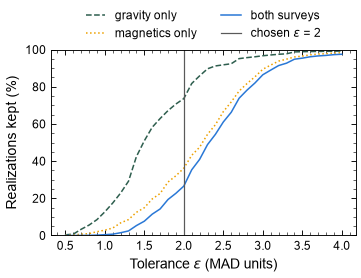

survivors at eps = 2: 2,656 of 10,000 (26.6%); written to wp4_ensemble_survivors.csv
kept at eps = 1.5 / 2 / 3: 7.7% / 26.6% / 86.5%
gravity alone keeps 73.6%, magnetics alone 36.2%
statistic with the largest |z| among the rejected:
m_residual_sd        3273
m_n_per_1e4km2        980
m_amp_median          641
m_amp_p90             617
g_width_median_km     538


In [5]:
LOGSTAT = {"amp_median", "amp_p90", "width_median_km", "residual_sd"}
EPS = 2.0
def zscores(ST):
    Z = {}
    for f in ("g", "m"):
        for key, _, _ in STATS:
            s, o = ST[f"{f}_{key}"].values.astype(float), OBS[f][key]
            if key in LOGSTAT: s, o = np.log(s), np.log(o)
            mad = 1.4826 * np.nanmedian(np.abs(s - np.nanmedian(s)))
            Z[f"{f}_{key}"] = np.where(np.isfinite(s), (s - o) / mad, np.inf)
    return pd.DataFrame(Z)

def falsify(ST, eps=EPS):
    """True = survives. Replace this function with another falsification algorithm; it must return one boolean per row of ST."""
    return (zscores(ST).abs() < eps).all(axis=1).values

Z = zscores(ST); KEEP = falsify(ST)
eps_grid = np.linspace(0.5, 4, 36)
acc = {lab: [(Z[cols].abs() < e).all(axis=1).mean() for e in eps_grid]
       for lab, cols in [("gravity only", [c for c in Z if c[0] == "g"]), ("magnetics only", [c for c in Z if c[0] == "m"]), ("both surveys", list(Z))]}
fig, ax = plt.subplots(figsize=(COL1, 2.6))
fig.subplots_adjust(left=0.18, right=0.97, top=0.82, bottom=0.17)
for (lab, a), col, ls in zip(acc.items(), ("#2e5e4e", "#eda100", C_KEEP), ("--", ":", "-")):
    ax.plot(eps_grid, np.array(a) * 100, color=col, ls=ls, label=lab)
ax.axvline(EPS, color="0.35", lw=0.8, label=f"chosen $\\epsilon$ = {EPS:g}")
ax.set_xlabel("Tolerance $\\epsilon$ (MAD units)"); ax.set_ylabel("Realizations kept (%)"); ax.set_ylim(0, 100)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=2)
fig.savefig(FIG / "wp4_ENS_03_screen_acceptance.png", dpi=300)
plt.show()
SURV = DR[KEEP].copy(); SURV.to_csv(GEN / "wp4_ensemble_survivors.csv", index=False)
worst = Z.abs().idxmax(axis=1)[~KEEP].value_counts()
print(f"survivors at eps = {EPS:g}: {KEEP.sum():,} of {N:,} ({KEEP.mean()*100:.1f}%); written to wp4_ensemble_survivors.csv")
print("kept at eps = 1.5 / 2 / 3: " + " / ".join(f"{(Z.abs() < e).all(axis=1).mean()*100:.1f}%" for e in (1.5, 2, 3)))
print(f"gravity alone keeps {acc['gravity only'][np.argmin(abs(eps_grid - EPS))]*100:.1f}%, magnetics alone {acc['magnetics only'][np.argmin(abs(eps_grid - EPS))]*100:.1f}%")
print("statistic with the largest |z| among the rejected:"); print(worst.head(5).to_string())

### How to read this figure

Each curve is the share of members kept as the tolerance $\epsilon$ widens, for each survey alone and for both; the vertical line is the chosen $\epsilon$ = 2.
- At $\epsilon$ = 2, 843 of 10,000 survive (8.4%); 1.1% at $\epsilon$ = 1.5 and 64.4% at 3.
- Gravity alone keeps 58.9%, magnetics alone 14.3%: magnetics does nearly all the falsifying, and the joint curve follows the magnetic one.
- Among rejected members the worst statistic is the magnetic anomaly count in 4,983 cases, then the magnetic residual sd in 1,240: the screen mainly enforces the Step 2 warning.

## Step 4. Prior falsification by robust Mahalanobis distance

Steps 2 and 3 compare hand-picked statistics. This step tests the prior as a whole on the data themselves (robust Mahalanobis distance falsification, after D. Yin, Stanford, 2019):

1. Remove the regional plane from every member and from the survey (the survey carries a regional level the zero-mean predictions do not).
2. Scale each data point to [-1, 1] over the 10,000 members and the survey together (`MinMaxScaler`).
3. Project onto the first 10 principal components of the members.
4. Fit a robust mean and covariance to the members' scores (minimum covariance determinant) and compute each member's robust Mahalanobis distance (RMD), and the survey's.
5. The prior is falsified if the survey's RMD exceeds the 95th percentile of the members' RMDs.

The 10 components carry only part of the variance, so the survey's share of variance outside them is also reported: a survey whose energy lies mostly outside the prior's leading components would pass the RMD test while still being unlike the prior.

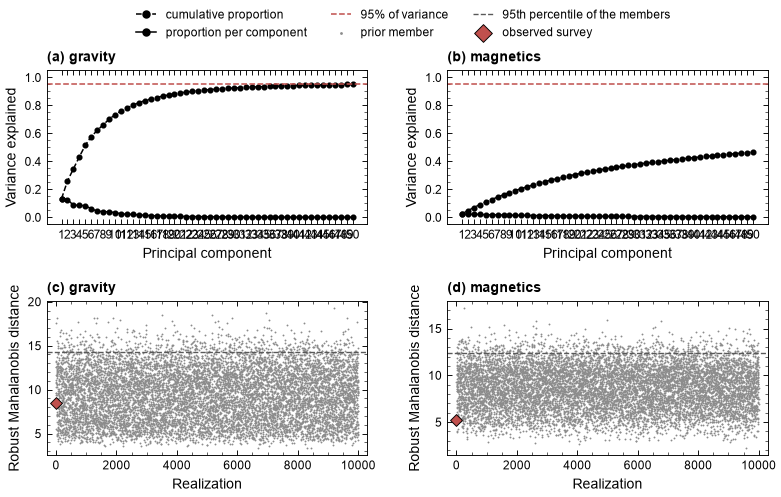

           survey  rmd_obs  rmd_q95  obs_percentile  falsified  var_in_10pcs  obs_share_in_10pcs  members_share_median  obs_share_percentile
          gravity    8.474   14.276           40.76      False         0.951               0.854                 0.951                  0.01
        magnetics    5.237   12.379            7.33      False         0.466               0.560                 0.462                 88.81
joint (20 scores)    9.063   15.932           14.02      False           NaN                 NaN                   NaN                   NaN


In [6]:
from sklearn.decomposition import PCA
from sklearn.covariance import MinCovDet

N_PCS, Q_RMD = 50, 95
def rmd_falsification(V, obs, P, n_pcs=N_PCS, q=Q_RMD):
    # V: members x data points (float32, modified in place); obs: survey at the same points
    A, Ap = (m.astype(np.float32) for m in P)
    for i in range(0, len(V), 500):
        V[i:i + 500] -= (V[i:i + 500] @ Ap.T) @ A.T                     # 1. remove the plane
    o = (obs - (obs @ Ap.T) @ A.T).astype(np.float32)[None, :]
    lo = np.minimum(V.min(0), o[0]); sc = 2 / (np.maximum(V.max(0), o[0]) - lo)   # 2. MinMaxScaler(-1, 1), fitted on members and survey
    for i in range(0, len(V), 500):
        V[i:i + 500] = (V[i:i + 500] - lo) * sc - 1
    o = (o - lo) * sc - 1
    pca = PCA(n_components=n_pcs, svd_solver="randomized", random_state=0).fit(V)   # 3. PCA (randomized: same leading components, far less memory)
    X, Xo = pca.transform(V), pca.transform(o)
    mcd = MinCovDet(random_state=0).fit(X); Pinv = np.linalg.inv(mcd.covariance_)  # 4. robust location and covariance
    md = np.sqrt(np.einsum("ij,jk,ik->i", X - mcd.location_, Pinv, X - mcd.location_))
    md_obs = np.sqrt((Xo - mcd.location_) @ Pinv @ (Xo - mcd.location_).T).item()
    tot = np.concatenate([((V[i:i + 500] - pca.mean_) ** 2).sum(1) for i in range(0, len(V), 500)]); tot_o = ((o - pca.mean_) ** 2).sum()
    return dict(evr=pca.explained_variance_ratio_, X=X, Xo=Xo, md=md, md_obs=md_obs, q_md=np.percentile(md, q),
                pct_obs=(md < md_obs).mean(), cap=(X ** 2).sum(1) / tot, cap_obs=float((Xo ** 2).sum() / tot_o))

RES = {"g": rmd_falsification(PRED_G.astype(np.float32), C.G_OBS, PG_)}
PRED_M = np.load(GEN / "pred_all.npz")["mag"]
RES["m"] = rmd_falsification(PRED_M, C.M_OBS, PM_); del PRED_M
XJ = np.c_[RES["g"]["X"], RES["m"]["X"]]; XJo = np.c_[RES["g"]["Xo"], RES["m"]["Xo"]]             # joint: both sets of scores
mcdJ = MinCovDet(random_state=0).fit(XJ); PJ = np.linalg.inv(mcdJ.covariance_)
mdJ = np.sqrt(np.einsum("ij,jk,ik->i", XJ - mcdJ.location_, PJ, XJ - mcdJ.location_))
RES["j"] = dict(md=mdJ, md_obs=np.sqrt((XJo - mcdJ.location_) @ PJ @ (XJo - mcdJ.location_).T).item(), q_md=np.percentile(mdJ, Q_RMD))
RES["j"]["pct_obs"] = (mdJ < RES["j"]["md_obs"]).mean()

fig, axes = plt.subplots(2, 2, figsize=(COL2, 4.6))
fig.subplots_adjust(left=0.08, right=0.99, top=0.87, bottom=0.11, wspace=0.25, hspace=0.5)
k = np.arange(1, N_PCS + 1)
for c, f in enumerate(("g", "m")):
    r = RES[f]; ax = axes[0, c]
    ax.plot(k, r["evr"].cumsum(), "o--", color="k", ms=3, label="cumulative proportion")
    ax.plot(k, r["evr"], "o-", color="k", ms=3, label="proportion per component")
    ax.axhline(0.95, color=C_OBS, ls="--", lw=1.0, label="95% of variance")
    ax.set_xticks(k); ax.xaxis.set_minor_locator(plt.NullLocator()); ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel("Principal component"); ax.set_ylabel("Variance explained")
    ax = axes[1, c]
    ax.scatter(np.arange(1, N + 1), r["md"], s=1.5, color=C_PRIOR, lw=0, rasterized=True, label="prior member")
    ax.axhline(r["q_md"], color="0.35", ls="--", lw=0.9, label=f"{Q_RMD}th percentile of the members")
    ax.scatter([0], [r["md_obs"]], marker="D", s=30, color=C_OBS, edgecolor="k", lw=0.6, zorder=5, label="observed survey")
    ax.set_xlim(-0.03 * N, 1.03 * N); ax.set_xlabel("Realization"); ax.set_ylabel("Robust Mahalanobis distance")
h1, l1 = axes[0, 0].get_legend_handles_labels(); h2, l2 = axes[1, 0].get_legend_handles_labels()
fig.legend(h1 + h2, l1 + l2, loc="upper center", ncol=3, bbox_to_anchor=(0.53, 1.01), markerscale=1.5)
panel_labels(axes.ravel(), ("(a) gravity", "(b) magnetics", "(c) gravity", "(d) magnetics"))
fig.savefig(FIG / "wp4_ENS_04_rmd_falsification.png", dpi=300)
plt.show()
RMD_TAB = pd.DataFrame([dict(survey=n, rmd_obs=RES[f]["md_obs"], rmd_q95=RES[f]["q_md"], obs_percentile=RES[f]["pct_obs"] * 100,
                             falsified=RES[f]["md_obs"] > RES[f]["q_md"],
                             var_in_10pcs=RES[f]["evr"].sum() if f != "j" else np.nan,
                             obs_share_in_10pcs=RES[f].get("cap_obs", np.nan), members_share_median=np.median(RES[f]["cap"]) if f != "j" else np.nan,
                             obs_share_percentile=(RES[f]["cap"] < RES[f]["cap_obs"]).mean() * 100 if f != "j" else np.nan)
                        for n, f in [("gravity", "g"), ("magnetics", "m"), ("joint (20 scores)", "j")]])
RMD_TAB.to_csv(GEN / "wp4_ensemble_rmd_falsification.csv", index=False)
print(RMD_TAB.round(3).to_string(index=False))

### How to read this figure

(a, b) Share of the members' variance carried by each of the first 10 principal components (solid) and cumulatively (dashed); the red dashed line is 95%. (c, d) Robust Mahalanobis distance of each of the 10,000 members (grey), their 95th percentile (dashed) and the survey (red diamond, placed at realization 0).
- Neither survey falsifies the prior: gravity RMD 1.918 against a 95th percentile of 5.127 (12.7th percentile of the members), magnetics 3.417 against 5.509 (54.4th); both together (20 scores) 3.598 against 6.478 (20.1th).
- The 10 components carry 78.5% of the gravity variance but only 24.1% of the magnetic variance: magnetic members are dominated by short-wavelength texture spread over many components, so the magnetic test sees about a quarter of the data.
- The survey's own share inside the 10 components adds what the distance misses: 59.5% for gravity (below 95% of members) and 49.9% for magnetics (above 99.6% of members, median 22.3%). The magnetic survey is much smoother than the prior's members, the same message as the Step 2 count warning.

## Step 5. Observed and simulated profiles

The same comparison as a west-east profile through the Olympic Dam northing: the plane-removed residual of all 10,000 members, gridded by the Step 2 rule, against the observed one.

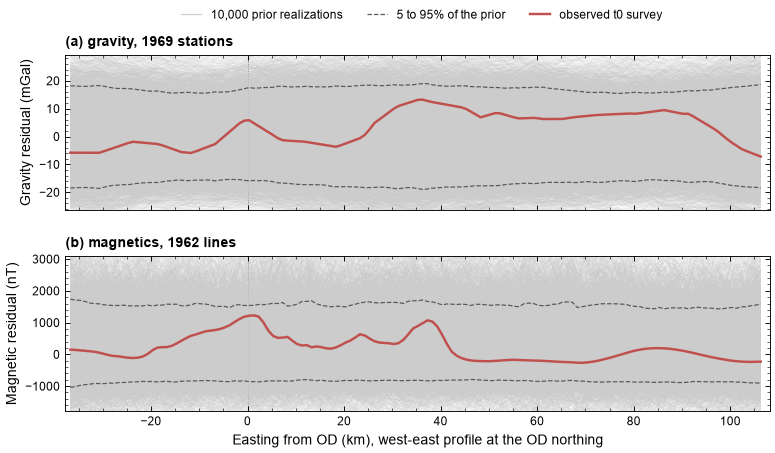

gravity: observed -7.2 to 13.2; inside the 5-95% band at 100% of points; envelope -19 to 19; at the OD easting 5.9, above 72% of members
magnetics: observed -266.0 to 1226.6; inside the 5-95% band at 100% of points; envelope -1041 to 1739; at the OD easting 1214.0, above 93% of members


In [7]:
import warnings; warnings.filterwarnings("ignore", message="All-NaN slice")   # grid columns outside the survey hull
iy = int(np.argmin(abs(C.YC - C.ODY))); xkm = (C.XC - C.ODX) / 1e3
rows = slice(iy * C.NX, (iy + 1) * C.NX)                              # grid row at the OD northing (grid is row-major, NY x NX)
PROF_G = np.asarray((WG[rows] @ remove_plane(PRED_G.astype(np.float64), PG_).T).T)
PRED_M = np.load(GEN / "pred_all.npz")["mag"]
PROF_M = np.vstack([np.asarray((WM[rows] @ remove_plane(PRED_M[i:i + 500].astype(np.float64), PM_).T).T) for i in range(0, N, 500)])
del PRED_M
PROF_G[:, ~OKG[iy]] = np.nan; PROF_M[:, ~OKM[iy]] = np.nan
OBS_PROF = {"g": np.where(OKG[iy], C.GRID_G[iy], np.nan), "m": np.where(OKM[iy], C.GRID_M[iy], np.nan)}
from matplotlib.collections import LineCollection
fig, axes = plt.subplots(2, 1, figsize=(COL2, 4.2), sharex=True)
fig.subplots_adjust(left=0.1, right=0.99, top=0.88, bottom=0.11, hspace=0.3)
PROF_SUM = []
for ax, prof, f, lab in [(axes[0], PROF_G, "g", "Gravity residual (mGal)"), (axes[1], PROF_M, "m", "Magnetic residual (nT)")]:
    ax.add_collection(LineCollection([np.c_[xkm, v] for v in prof], colors="0.8", linewidths=0.25, alpha=0.25, zorder=1, rasterized=True))
    lo, hi = np.nanpercentile(prof, [5, 95], axis=0)
    ax.plot(xkm, lo, color="0.35", lw=0.8, ls="--", zorder=2); ax.plot(xkm, hi, color="0.35", lw=0.8, ls="--", zorder=2)
    obs = OBS_PROF[f]; ax.plot(xkm, obs, color=C_OBS, lw=1.6, zorder=4)
    ax.axvline(0, color="k", lw=0.6, ls=":", zorder=0); ax.set_ylabel(lab); ax.set_xlim(xkm[0], xkm[-1])
    ok = np.isfinite(obs)
    ax.set_ylim(np.nanpercentile(np.r_[prof[:, ok].ravel(), obs[ok]], 0.5), np.nanpercentile(np.r_[prof[:, ok].ravel(), obs[ok]], 99.5))
    PROF_SUM.append(dict(field={"g": "gravity", "m": "magnetics"}[f], obs_min=np.nanmin(obs), obs_max=np.nanmax(obs),
                         inside_all=((obs[ok] >= lo[ok]) & (obs[ok] <= hi[ok])).mean(),
                         env_all=f"{np.nanmin(lo[ok]):.0f} to {np.nanmax(hi[ok]):.0f}",
                         obs_at_OD=obs[np.argmin(abs(xkm))], obs_q_at_OD=(prof[:, np.argmin(abs(xkm))] < obs[np.argmin(abs(xkm))]).mean()))
axes[1].set_xlabel("Easting from OD (km), west-east profile at the OD northing")
panel_labels(axes, ("(a) gravity, 1969 stations", "(b) magnetics, 1962 lines"))
fig.legend(handles=[plt.Line2D([], [], color="0.8", lw=0.8, label=f"{N:,} prior realizations"),
                    plt.Line2D([], [], color="0.35", lw=0.8, ls="--", label="5 to 95% of the prior"),
                    plt.Line2D([], [], color=C_OBS, lw=1.6, label="observed t0 survey")],
           loc="upper center", ncol=3, bbox_to_anchor=(0.55, 1.0))
fig.savefig(FIG / "wp4_ENS_05_profiles_observed_vs_prior.png", dpi=300)
plt.show()
PS = pd.DataFrame(PROF_SUM)
for _, r in PS.iterrows():
    print(f"{r.field}: observed {r.obs_min:.1f} to {r.obs_max:.1f}; inside the 5-95% band at {r.inside_all*100:.0f}% of points; envelope {r.env_all}; "
          f"at the OD easting {r.obs_at_OD:.1f}, above {r.obs_q_at_OD*100:.0f}% of members")

### How to read this figure

Each panel is a west-east line through the Olympic Dam northing (dotted at the deposit easting). Grey lines are all 10,000 prior realizations, the dashed lines their 5 to 95% envelope, and red the survey, all after removing a regional plane. Magnetics starts at about 45 km west, where the 1962 lines end.
- Gravity: the survey (-4.4 to 12.4 mGal) stays inside the envelope along the whole line; the prior swings more widely (-18 to 19 mGal), from its 30 km basement domains.
- Magnetics: the survey (-381 to 1,225 nT) is inside the envelope (-951 to 1,594 nT) at every point.
- At the OD easting the survey reads 6.8 mGal, above 75% of members, and 1,219 nT, above 93%: the target sits in the upper tail of what the prior produces at that point, most clearly in magnetics.

## Step 6. Which prior draws the surveys constrain

For each of the realization-level draws, the Kolmogorov-Smirnov distance between its distribution in all 10,000 members and in the survivors: 0 means the surveys say nothing about that draw, larger means the screen moved it. Panels (b) to (d) show the three most constrained draws.

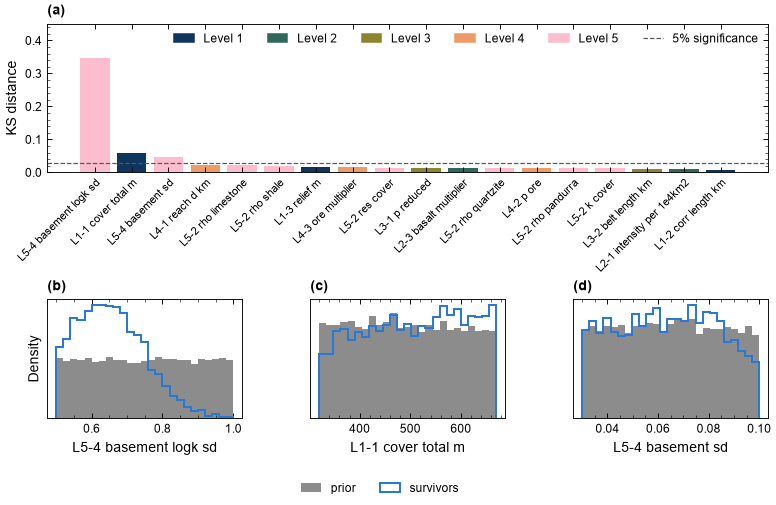

5% critical KS distance for 10,000 against 2,656: 0.030; draws above it: 3
                     draw    ks  prior_median  survivor_median
    L5-4 basement_logk_sd 0.347         0.752            0.649
       L1-1 cover_total_m 0.059       490.229          510.299
         L5-4 basement_sd 0.047         0.065            0.064
          L4-1 reach_d_km 0.023         7.481            7.740
       L5-2 rho_limestone 0.022         2.452            2.442
           L5-2 rho_shale 0.018         2.350            2.345
            L1-3 relief_m 0.016        74.638           74.718
      L4-3 ore_multiplier 0.016         2.984            2.994
           L5-2 res_cover 0.015        31.682           33.596
           L3-1 p_reduced 0.014         0.178            0.180
   L2-3 basalt_multiplier 0.014         9.534            9.369
       L5-2 rho_quartzite 0.014         2.650            2.650
               L4-2 p_ore 0.013         0.219            0.219
        L5-2 rho_pandurra 0.013         2.4

In [8]:
KS = pd.DataFrame([dict(draw=c, ks=stats.ks_2samp(DR[c], SURV[c]).statistic, prior_median=DR[c].median(), survivor_median=SURV[c].median())
                   for c in DRAW_COLS]).sort_values("ks", ascending=False).reset_index(drop=True)
LEVEL_COL = {k: BATLOW(v) for k, v in zip(range(1, 6), (0.08, 0.30, 0.52, 0.74, 0.92))}
fig = plt.figure(figsize=(COL2, 4.6))
gs = fig.add_gridspec(2, 3, height_ratios=[1.25, 1], hspace=0.95, wspace=0.35, left=0.08, right=0.99, top=0.95, bottom=0.17)
ax = fig.add_subplot(gs[0, :])
ax.bar(np.arange(len(KS)), KS.ks, color=[LEVEL_COL[int(d[1])] for d in KS.draw])
ax.set_xticks(np.arange(len(KS))); ax.set_xticklabels([d.replace("_", " ") for d in KS.draw], rotation=45, ha="right", rotation_mode="anchor", fontsize=FS_ANNOT)
ax.xaxis.set_minor_locator(plt.NullLocator()); ax.set_ylabel("KS distance")
KS_CRIT = 1.358 * np.sqrt(1 / N + 1 / KEEP.sum())                      # two-sample KS, 5% level
ax.axhline(KS_CRIT, color="0.35", lw=0.8, ls="--", label="5% significance")
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c, label=f"Level {k}") for k, c in LEVEL_COL.items()] + [plt.Line2D([], [], color="0.35", lw=0.8, ls="--", label="5% significance")], ncol=6, loc="upper right")
ax.set_ylim(0, KS.ks.max() * 1.3)
sub = [fig.add_subplot(gs[1, j]) for j in range(3)]
for a, d in zip(sub, KS.draw[:3]):
    bins = np.histogram_bin_edges(DR[d], 25)
    a.hist(DR[d], bins=bins, density=True, color=C_PRIOR, label="prior")
    a.hist(SURV[d], bins=bins, density=True, histtype="step", color=C_KEEP, lw=1.3, label="survivors")
    a.set_xlabel(d.replace("_", " ")); a.set_yticks([]); a.yaxis.set_minor_locator(plt.NullLocator())
sub[0].set_ylabel("Density")
fig.legend(*sub[0].get_legend_handles_labels(), loc="lower center", bbox_to_anchor=(0.5, 0.0), ncol=2)
panel_labels([ax] + sub, ("(a)", "(b)", "(c)", "(d)"))
fig.savefig(FIG / "wp4_ENS_06_constrained_draws.png", dpi=300)
plt.show()
KS.to_csv(GEN / "wp4_ensemble_ks_draws.csv", index=False)
print(f"5% critical KS distance for {N:,} against {KEEP.sum():,}: {KS_CRIT:.3f}; draws above it: {int((KS.ks > KS_CRIT).sum())}")
print(KS.round(3).to_string(index=False))

### How to read this figure

(a) KS distance per draw, coloured by level; the dashed line is the 5% significance level for 10,000 against 843 members (0.049). (b) to (d) Prior (grey) and survivors (blue outline) for the three draws above it.
- Only three draws move: the basement log-susceptibility spread (KS 0.158; survivor median 0.709 against 0.749 decades), the total cover (0.144; 537 against 490 m) and the basement density spread (0.105; 0.060 against 0.065 g/cm$^3$). The Pandurra density sits at the threshold (0.048).
- All three set the regional background. The basalt, redox and ore draws (Levels 2 to 4) stay at noise level (0.025 to 0.035): the window statistics do not see them.
- Fewer magnetic anomalies need a smoother basement under thicker cover, as Step 13 of the prior notebook suggested.

## Step 7. What the screen does to the ore question

Ore is not written into the property volumes (the blanket's density contrast is a few hundredths of a g/cm$^3$), so the surveys can only reach it through the geology it needs: basalt piles, their reach and reduced facies. This step compares the ore summaries before and after the screen.

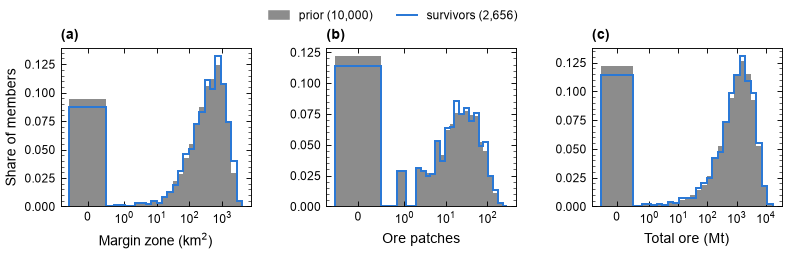

prior    : no ore in the window  12.2% (95% CI 11.6-12.9); median zone    364 km2; median patches   17; median total ore     912 Mt
survivors: no ore in the window  11.4% (95% CI 10.3-12.7); median zone    374 km2; median patches   18; median total ore     942 Mt


In [9]:
def boot_ci(x, f=np.mean, B=2000, seed=0):
    r = np.random.default_rng(seed); x = np.asarray(x)
    v = [f(x[r.integers(0, len(x), len(x))]) for _ in range(B)]; return np.percentile(v, [2.5, 97.5])
fig, axes = plt.subplots(1, 3, figsize=(COL2, 2.4))
fig.subplots_adjust(left=0.08, right=0.99, top=0.84, bottom=0.24, wspace=0.4)
for ax, col, lab in [(axes[0], "zone_km2", "Margin zone (km$^2$)"), (axes[1], "n_ore", "Ore patches"), (axes[2], "Mt_total", "Total ore (Mt)")]:
    a, b = DR[col].values, SURV[col].values
    bins = np.r_[-0.5, np.geomspace(0.5, max(a.max(), 1) * 1.1, 25)]
    ax.hist(a, bins=bins, weights=np.full(len(a), 1 / len(a)), color=C_PRIOR)
    ax.hist(b, bins=bins, weights=np.full(len(b), 1 / len(b)), histtype="step", color=C_KEEP, lw=1.3)
    ax.set_xscale("symlog", linthresh=1); ax.set_xlabel(lab)
axes[0].set_ylabel("Share of members")
fig.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=C_PRIOR, label=f"prior ({N:,})"),
                    plt.Line2D([], [], color=C_KEEP, lw=1.3, label=f"survivors ({KEEP.sum():,})")], loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02))
panel_labels(axes, ("(a)", "(b)", "(c)"))
fig.savefig(FIG / "wp4_ENS_07_ore_before_after.png", dpi=300)
plt.show()
for lab, d in [("prior", DR), ("survivors", SURV)]:
    ci = boot_ci((d.n_ore == 0).values)
    print(f"{lab:9s}: no ore in the window {(d.n_ore == 0).mean()*100:5.1f}% (95% CI {ci[0]*100:.1f}-{ci[1]*100:.1f}); "
          f"median zone {d.zone_km2.median():6.0f} km2; median patches {d.n_ore.median():4.0f}; median total ore {d.Mt_total.median():7,.0f} Mt")

### How to read this figure

Bars are the share of members per bin: grey the 10,000 prior members, blue outline the 843 survivors. The axes are linear up to 1 and logarithmic above, so the first bar is the members with no margin zone, no patch or no ore.
- No ore anywhere in the window: 14.9% of the prior (95% interval 14.2 to 15.6) and 13.8% of the survivors (11.6 to 16.3), indistinguishable.
- Medians, prior against survivors: margin zone 280 against 292 km$^2$, patches 13 against 12, total ore 690 against 668 Mt.
- The screen leaves the ore question where the prior put it: the surveys see the basement, not the blanket (the conditional independence of the prior notebook).

## Step 8. Point-wise misfit and why weighting collapses

The alternative to screening is likelihood weighting (prior notebook Step 18): after removing a regional plane, the normalized misfit per survey is $\chi^2/n = \frac{1}{n}\sum_i (r_i/\sigma_i)^2$ ($\sigma$ about 1 mGal and 5 nT). Tempering the Gaussian likelihood by $\tau$, $w \propto \exp(-\chi^2 / 2\tau)$, shows how much model error would have to be admitted before the weights spread over more than a handful of members; the effective sample size is $\mathrm{ESS} = 1/\sum w^2$.

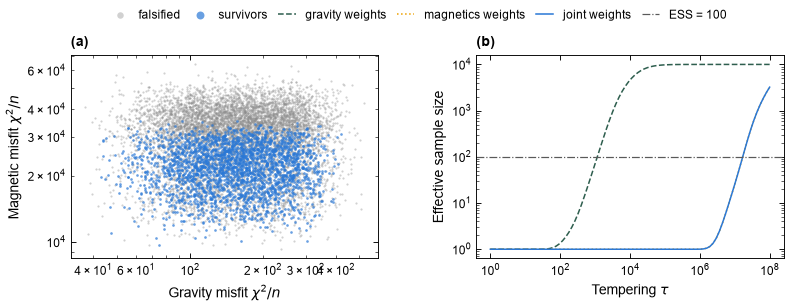

best normalized misfit: gravity 36.9 (median 156.5); magnetics 9269 (median 27982)
ESS at tau = 1: gravity 1.00, magnetics 1.00, joint 1.00
tau needed for ESS >= 100: gravity 1,400, magnetics 19,094,086, joint 19,094,086
Spearman correlation, survivor flag vs gravity misfit -0.01, vs magnetic misfit -0.40


In [10]:
PRED_M = np.load(GEN / "pred_all.npz")["mag"]
def chi2(V, obs, sd, P, B=500):
    out = np.empty(len(V))
    for i in range(0, len(V), B):
        D = remove_plane(obs[None, :] - V[i:i + B].astype(np.float64), P)
        out[i:i + B] = ((D / sd) ** 2).sum(1)
    return out
CHI_G = chi2(PRED_G, C.G_OBS, C.G_SD, PG_); CHI_M = chi2(PRED_M, C.M_OBS, C.RULE["mag_noise_nt"], PM_)
del PRED_M
nG, nM = len(C.G_OBS), len(C.M_OBS)
def ess(chi, tau):
    lw = -chi / (2 * tau); w = np.exp(lw - lw.max()); w /= w.sum(); return 1 / (w ** 2).sum()
taus = np.geomspace(1, 1e8, 90)
E = {lab: np.array([ess(ch, t) for t in taus]) for lab, ch in [("gravity", CHI_G), ("magnetics", CHI_M), ("joint", CHI_G + CHI_M)]}
fig, axes = plt.subplots(1, 2, figsize=(COL2, 2.8))
fig.subplots_adjust(left=0.09, right=0.99, top=0.84, bottom=0.18, wspace=0.32)
ax = axes[0]
ax.scatter(CHI_G[~KEEP] / nG, CHI_M[~KEEP] / nM, s=2, color=C_PRIOR, alpha=0.4, lw=0, label="falsified")
ax.scatter(CHI_G[KEEP] / nG, CHI_M[KEEP] / nM, s=3, color=C_KEEP, alpha=0.7, lw=0, label="survivors")
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlabel("Gravity misfit $\\chi^2/n$"); ax.set_ylabel("Magnetic misfit $\\chi^2/n$")
ax = axes[1]
for (lab, e), col, ls in zip(E.items(), ("#2e5e4e", "#eda100", C_KEEP), ("--", ":", "-")):
    ax.plot(taus, e, color=col, ls=ls, label=f"{lab} weights")
ax.axhline(100, color="0.35", lw=0.8, ls="-.", label="ESS = 100")
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlabel("Tempering $\\tau$"); ax.set_ylabel("Effective sample size")
h1, l1 = axes[0].get_legend_handles_labels(); h2, l2 = axes[1].get_legend_handles_labels()
fig.legend(h1 + h2, l1 + l2, loc="upper center", ncol=6, bbox_to_anchor=(0.53, 1.02), markerscale=3, handlelength=1.4, columnspacing=0.9)
panel_labels(axes, ("(a)", "(b)"))
fig.savefig(FIG / "wp4_ENS_08_misfit_and_ess.png", dpi=300)
plt.show()
need = {lab: taus[np.argmax(e >= 100)] if (e >= 100).any() else np.nan for lab, e in E.items()}
print(f"best normalized misfit: gravity {CHI_G.min()/nG:.1f} (median {np.median(CHI_G)/nG:.1f}); magnetics {CHI_M.min()/nM:.0f} (median {np.median(CHI_M)/nM:.0f})")
print(f"ESS at tau = 1: gravity {E['gravity'][0]:.2f}, magnetics {E['magnetics'][0]:.2f}, joint {E['joint'][0]:.2f}")
print("tau needed for ESS >= 100: " + ", ".join(f"{k} {v:,.0f}" for k, v in need.items()))
print(f"Spearman correlation, survivor flag vs gravity misfit {stats.spearmanr(KEEP, CHI_G)[0]:+.2f}, vs magnetic misfit {stats.spearmanr(KEEP, CHI_M)[0]:+.2f}")

### How to read this figure

(a) Each dot is one member: normalized misfit to the gravity stations against the magnetic readings, after removing a plane; blue are the Step 3 survivors. (b) Effective sample size of the likelihood weights as the likelihood is tempered ($\tau$ = 1 is the plain Gaussian with survey noise); the magnetic curve lies under the joint one.
- The best member misfits gravity by $\chi^2/n$ = 27.4 (median 135.6) and magnetics by 9,315 (median 29,052): no prior member reproduces the surveys point by point, as expected when basement domains are placed at random.
- At $\tau$ = 1 the ESS is 1.00 for each survey, all weight on one member. Gravity needs $\tau$ of about 925 to reach ESS 100; magnetics and the joint weights need about 1.3 x 10$^7$.
- Survivors are spread through the cloud (Spearman -0.07 and -0.06): the statistical screen and the point-wise misfit measure different things.

## What this shows

1. The prior passes the Section 4 gate on 10,000 members as it did on 200: gravity five of five, magnetics four of five, with the magnetic count warning ($q$ = 0.008).
2. 843 members (8.4%) survive the $|z| < 2$ screen; the magnetic anomaly count is the main reason for rejection.
3. The prior as a whole is not falsified by the robust Mahalanobis test, for either survey or both. The 10 leading components hold only 24% of the magnetic variance, though, and the magnetic survey is smoother than 99.6% of the members by its share of energy in them.
4. Survivors differ from the prior in three regional draws only: a smoother basement susceptibility, thicker cover and a smoother basement density. Levels 2 to 4 are unconstrained.
5. The ore question does not move (13.8% against 14.9% without ore). Through this prior, the window-scale t0 potential fields carry no information on ore; any class discrimination has to come from target-level statistics.
6. Point-wise likelihood weighting collapses (ESS 1) and needs an admitted model error of $\tau$ about 10$^3$ (gravity) to 10$^7$ (magnetics) to spread; screening on statistics, or a likelihood on target statistics, is the workable route.

## Next steps

1. **Settle the falsification rule.** Step 4 (RMD) tests the prior as a whole and does not falsify it; Step 3 filters members, and Steps 6 to 8 use its output through `falsify()`. For the RMD test, use more components for magnetics (or the gridded maps) so it covers more than a quarter of the variance, and report the survey's share outside the components with the distance. Freeze the rule with a version tag before comparing classes.
2. **Rebuild survivor volumes on demand.** `C.realize(seed, keep_volume=True)` regenerates any survivor exactly (about 1 s); store volumes only for the models you carry forward.
3. **Define the classes at the target.** Label each member by ore beneath the OD anomaly (or inside the target circle) rather than anywhere in the window, and set the class priors from the residual rule ($P(\text{min}) = 0.05$), not from the sampler's ore frequency.
4. **Add target-level statistics.** Window statistics mostly reflect the shared basement background; a local window (30 to 40 km) around the OD anomaly with its peak, width, gravity-magnetic offset and amplitude ratio is where the classes can differ.
5. **Class-conditioned ensembles and the Bayes factor.** Generate barren and stratiform-Cu ensembles with per-level random streams (paired seeds), estimate $p(\mathbf{s} \mid M_i)$ on the target statistics by synthetic likelihood or ABC, and track $\log$ BF with a bootstrap interval and a convergence check against $N$.
6. **Keep the residual class in the comparison.** Track $P(\text{residual} \mid D)$ and a joint adequacy check at every data increment; a rise signals that no listed class explains the data.